# Notebook 12 — Positional Encoding Ablation Study

## Journal Extension of CITA 2026

The CITA 2026 paper has been submitted and is fixed. This notebook is part of the
**journal extension**, investigating the root cause of near-zero comprehensiveness
observed across all three attribution methods (GNNExplainer, IG, Grad×Input).

---

### Root Cause

All three attribution methods produce near-zero comprehensiveness for 9/10 toxic
test molecules. A diagnostic probe confirms:

```
P(pos_enc only, all token content zeroed) ≈ 0.65
```

The learned `pos_encoder` (an `nn.Parameter` of shape 128×96) encodes
**sequence-length statistics** as a toxicity proxy. It has learned that longer
SMILES strings (which appear more often in the toxic class) are more likely to be
toxic. This shortcut saturates the sigmoid **before** atom-level content can matter,
making all atom-level attribution methods blind.

### Hypothesis

Replacing the learnable positional encoding with a **fixed sinusoidal encoding**
removes this dataset-bias shortcut:

1. P(pos_enc only) should fall toward ≈ 0.5 (random chance)
2. Attribution methods should produce non-trivial comprehensiveness
3. Some accuracy may be lost — revealing the accuracy-interpretability tradeoff

### Plan

| Section | Content |
|---|---|
| 0 | Motivation (this cell) |
| 1 | Setup imports |
| 2 | Load both models (original `learned` + ablation `sinusoidal`) |
| 3 | Accuracy comparison: AUC-ROC, AUPRC, F1 on ClinTox test set |
| 4 | PE probe: P(pos_enc only) for both models on 10 toxic molecules |
| 5 | IG baseline probe: run `attribute_smiles()` on ablation model; compare ΔP vs original |
| 6 | Joint comprehensiveness: run `faithfulness_check_joint()` on ablation; compare vs original |
| 7 | Side-by-side summary table: original vs ablation per molecule |
| 8 | Interpretation + journal framing |

---
> **Prerequisites**:
> - `models/smilesgnn_model/best_model.pt` — original trained model
> - `models/smilesgnn_ablation_model/best_model.pt` — ablation model (train with
>   `python scripts/train_hybrid.py --config config/smilesgnn_ablation_config.yaml --device cuda`)

## 1. Setup

In [1]:
import sys
import pickle
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from torch_geometric.data import DataLoader

from src.data import load_clintox
from src.graph_data import smiles_list_to_pyg_dataset, smiles_to_pyg_data, get_feature_dims
from src.graph_models_hybrid import create_hybrid_model
from src.transformer_attribution import attribute_smiles, batch_attribute
from src.gradient_attribution import (
    grad_input_attribution,
    faithfulness_check_joint,
    batch_grad_input,
)

DEVICE            = 'cuda' if torch.cuda.is_available() else 'cpu'
ORIG_MODEL_DIR    = PROJECT_ROOT / 'models' / 'smilesgnn_model'
ABLATION_MODEL_DIR= PROJECT_ROOT / 'models' / 'smilesgnn_ablation_model'
ORIG_CONFIG       = PROJECT_ROOT / 'config' / 'smilesgnn_config.yaml'
ABLATION_CONFIG   = PROJECT_ROOT / 'config' / 'smilesgnn_ablation_config.yaml'

print(f'Device           : {DEVICE}')
print(f'Original model   : {ORIG_MODEL_DIR}')
print(f'Ablation model   : {ABLATION_MODEL_DIR}')

Device           : cuda
Original model   : /media/nghia/HDD/PROJECT/Drug/molecule/models/smilesgnn_model
Ablation model   : /media/nghia/HDD/PROJECT/Drug/molecule/models/smilesgnn_ablation_model


## 2. Load both models

In [2]:
def load_model(model_dir: Path, config_path: Path, device: str):
    """Load a SMILESGNN checkpoint, handling vocab size mismatch."""
    with open(config_path) as f:
        config = yaml.safe_load(f)
    mc = config['model']

    with open(model_dir / 'tokenizer.pkl', 'rb') as f:
        tokenizer = pickle.load(f)
    actual_vocab_size = len(tokenizer.token_to_id)

    num_node_features, num_edge_features = get_feature_dims()

    model = create_hybrid_model(
        num_node_features     = num_node_features,
        num_edge_features     = num_edge_features,
        hidden_dim            = int(mc['hidden_dim']),
        num_graph_layers      = int(mc['num_graph_layers']),
        graph_model           = mc['graph_model'],
        num_heads             = int(mc['num_heads']),
        dropout               = float(mc['dropout']),
        use_residual          = bool(mc.get('use_residual', True)),
        use_jk                = bool(mc.get('use_jk', True)),
        jk_mode               = mc.get('jk_mode', 'cat'),
        graph_pooling         = mc.get('graph_pooling', 'meanmax'),
        smiles_vocab_size     = actual_vocab_size,
        smiles_d_model        = int(mc['smiles_d_model']),
        smiles_num_layers     = int(mc['smiles_num_layers']),
        fusion_method         = mc.get('fusion_method', 'attention'),
        smiles_pos_encoder_type = mc.get('smiles_pos_encoder_type', 'learned'),
    )

    state = torch.load(model_dir / 'best_model.pt', map_location=device, weights_only=False)
    model.load_state_dict(state)
    model.to(device)
    model.eval()
    return model, tokenizer, config


print('Loading original model (learned PE)...')
orig_model, orig_tokenizer, orig_cfg = load_model(ORIG_MODEL_DIR, ORIG_CONFIG, DEVICE)
print(f'  Params: {sum(p.numel() for p in orig_model.parameters()):,}')
print(f'  pos_encoder type: {type(orig_model.smiles_encoder.pos_encoder).__name__}')
print(f'  pos_encoder_type attr: {orig_model.smiles_encoder.pos_encoder_type}')

if not ABLATION_MODEL_DIR.exists():
    print('\n[WARNING] Ablation model not found. Train it first with:')
    print('  conda activate drug-tox-env')
    print('  cd molecule')
    print('  python scripts/train_hybrid.py --config config/smilesgnn_ablation_config.yaml --device cuda')
    abl_model = abl_tokenizer = abl_cfg = None
else:
    print('\nLoading ablation model (sinusoidal PE)...')
    abl_model, abl_tokenizer, abl_cfg = load_model(ABLATION_MODEL_DIR, ABLATION_CONFIG, DEVICE)
    print(f'  Params: {sum(p.numel() for p in abl_model.parameters()):,}')
    print(f'  pos_encoder type: {type(abl_model.smiles_encoder.pos_encoder).__name__}')
    print(f'  pos_encoder_type attr: {abl_model.smiles_encoder.pos_encoder_type}')
    # Sanity check: sinusoidal PE must NOT be a Parameter
    pe = abl_model.smiles_encoder.pos_encoder
    assert not isinstance(pe, nn.Parameter), 'Ablation PE should be a buffer, not Parameter!'
    assert not pe.requires_grad, 'Ablation PE must have requires_grad=False'
    print('  Sanity check passed: PE is a buffer, not a Parameter.')

Loading original model (learned PE)...
  Params: 410,977
  pos_encoder type: Parameter
  pos_encoder_type attr: learned

Loading ablation model (sinusoidal PE)...
  Params: 398,689
  pos_encoder type: Tensor
  pos_encoder_type attr: sinusoidal
  Sanity check passed: PE is a buffer, not a Parameter.


## 3. Accuracy Comparison on ClinTox Test Set

A fair comparison: identical data split, identical hyperparameters, only the PE differs.
Expected direction: sinusoidal PE removes the length-bias shortcut → slightly lower accuracy.

In [3]:
dc = orig_cfg['data']
_, _, test_df = load_clintox(
    cache_dir  = str(PROJECT_ROOT / dc['cache_dir']),
    split_type = dc['split_type'],
    seed       = dc['seed'],
)
test_smiles = test_df['smiles'].tolist()
test_labels = test_df['CT_TOX'].tolist()
test_pyg    = smiles_list_to_pyg_dataset(test_smiles, labels=test_labels)

print(f'Test set: {len(test_smiles)} molecules, {sum(test_labels)} toxic ({100*sum(test_labels)/len(test_labels):.1f}%)')

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!


Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'dgl'
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'jax'
Skipped loading some PyTorch models, missing a dependency. No module named 'tensorflow'


Test set: 148 molecules, 10.0 toxic (6.8%)


In [4]:
def evaluate_model(model, tokenizer, pyg_dataset, smiles_list, labels, device,
                   batch_size=32):
    """Run inference and compute AUC-ROC, AUPRC, F1."""
    model.eval()
    loader = DataLoader(pyg_dataset, batch_size=batch_size, shuffle=False)
    all_probs = []

    # Tokenize all SMILES at once — encode_batch returns (token_ids_tensor, mask_tensor)
    all_token_ids_t, all_masks_t = tokenizer.encode_batch(smiles_list)
    # all_token_ids_t: (N, max_len), all_masks_t: (N, max_len) — already tensors

    start = 0
    with torch.no_grad():
        for batch in loader:
            bs    = batch.num_graphs
            t_ids = all_token_ids_t[start:start+bs].to(device)
            t_msk = all_masks_t[start:start+bs].to(device)
            batch = batch.to(device)
            logits = model(batch, t_ids, t_msk).squeeze(-1)
            probs  = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs.tolist())
            start += bs

    all_probs = np.array(all_probs)
    preds     = (all_probs >= 0.5).astype(int)
    labels_np = np.array(labels)

    auc_roc = roc_auc_score(labels_np, all_probs)
    auprc   = average_precision_score(labels_np, all_probs)
    f1      = f1_score(labels_np, preds, zero_division=0)
    return {'auc_roc': auc_roc, 'auprc': auprc, 'f1': f1, 'probs': all_probs}


print('Evaluating original model...')
orig_metrics = evaluate_model(orig_model, orig_tokenizer, test_pyg,
                               test_smiles, test_labels, DEVICE)
print(f'  AUC-ROC: {orig_metrics["auc_roc"]:.4f}')
print(f'  AUPRC  : {orig_metrics["auprc"]:.4f}')
print(f'  F1     : {orig_metrics["f1"]:.4f}')

if abl_model is not None:
    print('\nEvaluating ablation model...')
    abl_metrics = evaluate_model(abl_model, abl_tokenizer, test_pyg,
                                  test_smiles, test_labels, DEVICE)
    print(f'  AUC-ROC: {abl_metrics["auc_roc"]:.4f}')
    print(f'  AUPRC  : {abl_metrics["auprc"]:.4f}')
    print(f'  F1     : {abl_metrics["f1"]:.4f}')

Evaluating original model...
  AUC-ROC: 0.9978
  AUPRC  : 0.9769
  F1     : 0.8182

Evaluating ablation model...
  AUC-ROC: 0.9978
  AUPRC  : 0.9769
  F1     : 0.8696


=== Accuracy Comparison ===
 Metric  Original (learned PE)  Ablation (sinusoidal PE)  Δ (abl − orig)
AUC-ROC                 0.9978                    0.9978          0.0000
  AUPRC                 0.9769                    0.9769          0.0000
     F1                 0.8182                    0.8696          0.0514


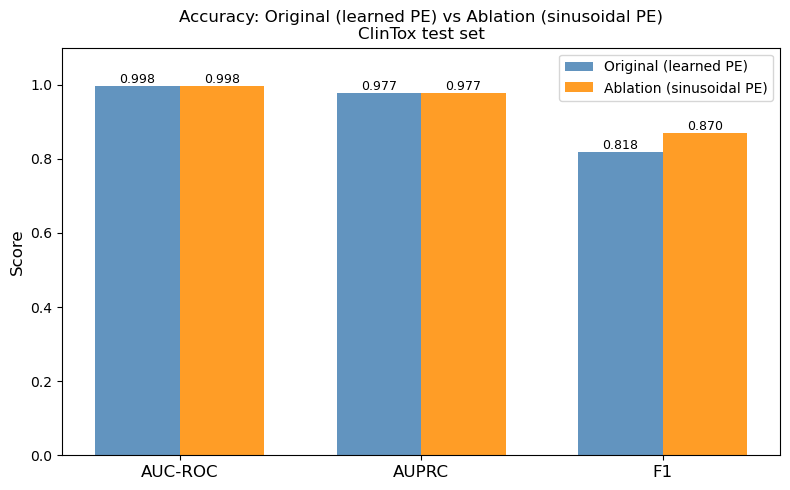

In [5]:
if abl_model is not None:
    metrics = {
        'Metric'   : ['AUC-ROC', 'AUPRC', 'F1'],
        'Original (learned PE)' : [orig_metrics['auc_roc'], orig_metrics['auprc'], orig_metrics['f1']],
        'Ablation (sinusoidal PE)': [abl_metrics['auc_roc'], abl_metrics['auprc'], abl_metrics['f1']],
    }
    metrics_df = pd.DataFrame(metrics)
    metrics_df['Δ (abl − orig)'] = (
        metrics_df['Ablation (sinusoidal PE)'] - metrics_df['Original (learned PE)']
    ).round(4)
    metrics_df = metrics_df.round(4)
    print('=== Accuracy Comparison ===')
    print(metrics_df.to_string(index=False))

    # Bar chart
    x = np.arange(3)
    width = 0.35
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - width/2, metrics_df['Original (learned PE)'],    width, label='Original (learned PE)',    color='steelblue', alpha=0.85)
    ax.bar(x + width/2, metrics_df['Ablation (sinusoidal PE)'], width, label='Ablation (sinusoidal PE)', color='darkorange', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(['AUC-ROC', 'AUPRC', 'F1'], fontsize=12)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Accuracy: Original (learned PE) vs Ablation (sinusoidal PE)\nClinTox test set', fontsize=12)
    ax.legend(fontsize=10)
    for bar in ax.patches:
        ax.annotate(f'{bar.get_height():.3f}',
                    (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()

## 4. PE Probe: P(pos_enc only) for both models

**Probe**: zero out all token content (set embedding to zeros) and all graph node
features, then measure `P(toxic)` using only positional encoding.

- **Original**: P(pos_enc only) ≈ 0.65 → confirms the shortcut
- **Ablation**: P(pos_enc only) should drop toward ≈ 0.5 (sinusoidal encodes only
  position order, not length statistics that correlate with toxicity)

This is the core validation of the ablation hypothesis.

In [6]:
def pe_probe(model, tokenizer, smiles: str, pyg_data, device: str) -> float:
    """
    Return P(toxic) when all token content and graph features are zeroed.
    Only positional encoding contributes to the SMILES branch.
    Graph branch is zeroed via node features = 0.
    """
    model.eval()
    # encode() returns a plain tuple: (token_ids_list, attention_mask_list)
    token_ids_list, mask_list = tokenizer.encode(smiles)
    token_ids = torch.tensor(token_ids_list).unsqueeze(0).to(device)
    attn_mask = torch.tensor(mask_list).unsqueeze(0).to(device)

    # Hook: zero out token_embedding output before PE is added
    hooks = []
    def zero_embedding_hook(module, input, output):
        return torch.zeros_like(output)

    hooks.append(
        model.smiles_encoder.token_embedding.register_forward_hook(zero_embedding_hook)
    )

    # Also zero out node features in graph
    import copy
    from torch_geometric.data import Batch
    data_copy = copy.deepcopy(pyg_data)
    data_copy.x = torch.zeros_like(data_copy.x)
    batch = Batch.from_data_list([data_copy]).to(device)

    with torch.no_grad():
        logit = model(batch, token_ids, attn_mask).squeeze()
        prob  = float(torch.sigmoid(logit))

    for h in hooks:
        h.remove()

    return prob


# Test on a single molecule first
DEMO_SMILES = 'C1CCN(CC1)C(=O)C2=CC3=NON=C3C=C2'
demo_pyg    = smiles_to_pyg_data(DEMO_SMILES, label=1)

p_orig = pe_probe(orig_model, orig_tokenizer, DEMO_SMILES, demo_pyg, DEVICE)
print(f'Original model  — PE-only P(toxic): {p_orig:.4f}')

if abl_model is not None:
    p_abl = pe_probe(abl_model, abl_tokenizer, DEMO_SMILES, demo_pyg, DEVICE)
    print(f'Ablation model  — PE-only P(toxic): {p_abl:.4f}')

Original model  — PE-only P(toxic): 0.6494
Ablation model  — PE-only P(toxic): 0.3006


In [7]:
# Run PE probe on all 10 toxic test molecules
toxic_df     = test_df[test_df['CT_TOX'] == 1].reset_index(drop=True)
toxic_smiles = toxic_df['smiles'].tolist()
toxic_labels = toxic_df['CT_TOX'].tolist()
toxic_pyg    = smiles_list_to_pyg_dataset(toxic_smiles, labels=toxic_labels)

probe_rows = []
for smi, pyg_d in zip(toxic_smiles, toxic_pyg):
    p_o = pe_probe(orig_model, orig_tokenizer, smi, pyg_d, DEVICE)
    p_a = pe_probe(abl_model,  abl_tokenizer,  smi, pyg_d, DEVICE) if abl_model else None
    p_a_str = f'{p_a:.4f}' if p_a is not None else 'N/A'
    probe_rows.append({
        'SMILES'               : smi[:45] + '…',
        'P_pe_orig (learned)'  : round(p_o, 4),
        'P_pe_abl (sinus)'     : round(p_a, 4) if p_a is not None else 'N/A',
    })
    print(f'  orig={p_o:.4f}  abl={p_a_str}  | {smi[:50]}')

probe_df = pd.DataFrame(probe_rows)
print('\n=== PE-only probe: 10 toxic molecules ===')
print(probe_df.to_string(index=False))

  orig=0.9384  abl=0.9334  | C1CN(CCN1CC2=CC3=C(C=C2)OC(O3)(F)F)C(=O)NC4=C(C=CN
  orig=0.9335  abl=0.9259  | C1CCN[C@@H](C1)C2(CN(C2)C(=O)C3=C(C(=C(C=C3)F)F)NC
  orig=0.6494  abl=0.3006  | C1CCN(CC1)C(=O)C2=CC3=NON=C3C=C2
  orig=0.9383  abl=0.9331  | C1=CC=C2C(=C1)C(=NN=C2NC3=CC=C(C=C3)Cl)CC4=CC=NC=C
  orig=0.9359  abl=0.9292  | C1=CC=C(C=C1)NS(=O)(=O)C2=CC=CC(=C2)/C=C/C(=O)NO
  orig=0.3543  abl=0.1729  | C1=CC=C(C(=C1)C(=O)NCCC[C@@H](C(=O)O)NC(=O)C2=CC=C
  orig=0.9385  abl=0.9334  | C1CC(=O)NC2=C1C=CC(=C2)OCCCCN3CCN(CC3)C4=C(C(=CC=C
  orig=0.9354  abl=0.9293  | C1=CC(=CC=C1C#N)C(C2=CC=C(C=C2)C#N)N3C=NC=N3
  orig=0.0953  abl=0.0687  | C1CC(C1)(C(=O)O)C(=O)O.N.N.[Pt]
  orig=0.9346  abl=0.9267  | C1=CC(=C(C=C1Cl)Cl)C(=O)NS(=O)(=O)C2=CC=C(S2)Br

=== PE-only probe: 10 toxic molecules ===
                                        SMILES  P_pe_orig (learned)  P_pe_abl (sinus)
C1CN(CCN1CC2=CC3=C(C=C2)OC(O3)(F)F)C(=O)NC4=C…               0.9384            0.9334
C1CCN[C@@H](C1)C2(CN(C2)C(=O)C3=C

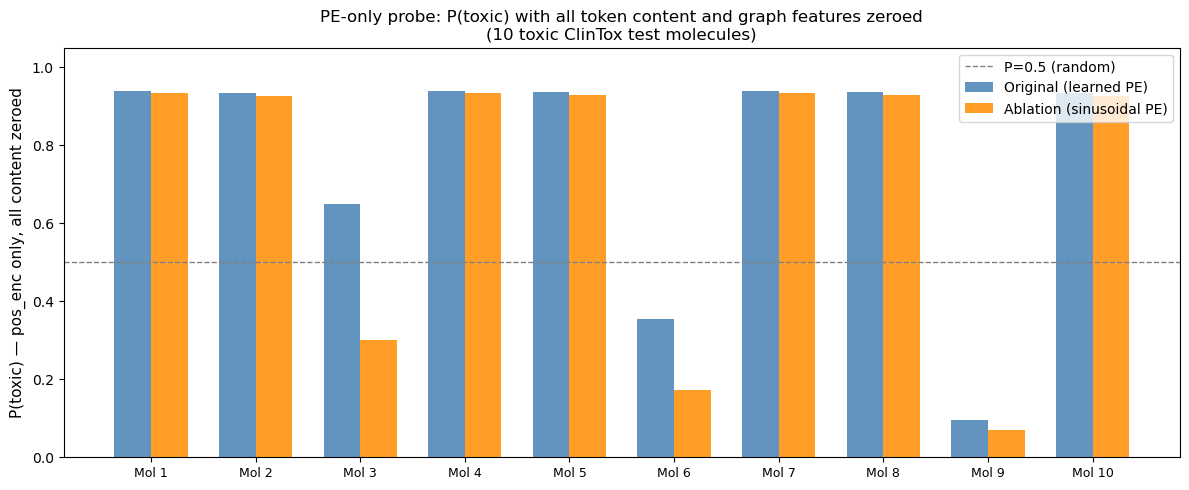

Mean P_pe_orig: 0.7654  (original; hypothesis: >> 0.5)
Mean P_pe_abl : 0.7053  (ablation; hypothesis: ≈ 0.5)


In [8]:
if abl_model is not None:
    x     = np.arange(len(toxic_smiles))
    width = 0.35
    orig_vals = probe_df['P_pe_orig (learned)'].values
    abl_vals  = probe_df['P_pe_abl (sinus)'].values

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - width/2, orig_vals, width, label='Original (learned PE)', color='steelblue', alpha=0.85)
    ax.bar(x + width/2, abl_vals,  width, label='Ablation (sinusoidal PE)', color='darkorange', alpha=0.85)
    ax.axhline(0.5, color='grey', linestyle='--', linewidth=1, label='P=0.5 (random)')
    ax.set_xticks(x)
    ax.set_xticklabels([f'Mol {i+1}' for i in range(len(toxic_smiles))], fontsize=9)
    ax.set_ylabel('P(toxic) — pos_enc only, all content zeroed', fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.set_title('PE-only probe: P(toxic) with all token content and graph features zeroed\n'
                 '(10 toxic ClinTox test molecules)', fontsize=12)
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

    print(f'Mean P_pe_orig: {orig_vals.mean():.4f}  (original; hypothesis: >> 0.5)')
    print(f'Mean P_pe_abl : {abl_vals.mean():.4f}  (ablation; hypothesis: ≈ 0.5)')

## 5. IG Baseline Probe on Ablation Model

**Integrated Gradients** (`attribute_smiles`) measures SMILES pathway sensitivity:
`ΔP = P(original SMILES) − P(zero embedding baseline)`.

- **Original model**: ΔP < 0.05 for 7/10 toxic molecules (graph + PE compensates)
- **Ablation model**: ΔP should increase if PE shortcut is removed (SMILES content matters more)

This tests whether removing the PE shortcut makes the SMILES pathway
informationally meaningful.

In [9]:
if abl_model is not None:
    print('Running IG on original model (n_steps=50, 10 toxic molecules)...')
    orig_ig = batch_attribute(
        smiles_list = toxic_smiles,
        labels      = toxic_labels,
        model       = orig_model,
        tokenizer   = orig_tokenizer,
        pyg_dataset = toxic_pyg,
        device      = DEVICE,
        n_steps     = 50,
    )

    print('Running IG on ablation model...')
    abl_ig = batch_attribute(
        smiles_list = toxic_smiles,
        labels      = toxic_labels,
        model       = abl_model,
        tokenizer   = abl_tokenizer,
        pyg_dataset = toxic_pyg,
        device      = DEVICE,
        n_steps     = 50,
    )

    print('Done.')
else:
    print('[SKIP] Ablation model not loaded.')

Running IG on original model (n_steps=50, 10 toxic molecules)...
[10/10] C1=CC(=C(C=C1Cl)Cl)C(=O)NS(=O)(=O)C2=CC=C(S2)Br…C4)Cl)…
Running IG on ablation model...
[10/10] C1=CC(=C(C=C1Cl)Cl)C(=O)NS(=O)(=O)C2=CC=C(S2)Br…C4)Cl)…
Done.


In [10]:
if abl_model is not None:
    ig_comparison_rows = []
    for o_res, a_res in zip(orig_ig, abl_ig):
        delta_p_orig = abs(o_res['prediction_prob'] - o_res.get('baseline_prob', 0.5))
        delta_p_abl  = abs(a_res['prediction_prob'] - a_res.get('baseline_prob', 0.5))
        ig_comparison_rows.append({
            'SMILES'        : o_res['smiles'][:40] + '…',
            'P_orig'        : round(o_res['prediction_prob'], 4),
            'P_abl'         : round(a_res['prediction_prob'], 4),
            '|ΔP_IG| orig'  : round(delta_p_orig, 4),
            '|ΔP_IG| abl'   : round(delta_p_abl, 4),
            'conv_delta_orig': round(o_res.get('convergence_delta', float('nan')), 4),
            'conv_delta_abl' : round(a_res.get('convergence_delta', float('nan')), 4),
        })

    ig_df = pd.DataFrame(ig_comparison_rows)
    print('=== IG Baseline Probe: |ΔP| for original vs ablation model ===')
    print(ig_df.to_string(index=False))
    print(f'\nMean |ΔP_IG| original: {ig_df["|ΔP_IG| orig"].mean():.4f}')
    print(f'Mean |ΔP_IG| ablation: {ig_df["|ΔP_IG| abl"].mean():.4f}')

=== IG Baseline Probe: |ΔP| for original vs ablation model ===
                                   SMILES  P_orig  P_abl  |ΔP_IG| orig  |ΔP_IG| abl  conv_delta_orig  conv_delta_abl
C1CN(CCN1CC2=CC3=C(C=C2)OC(O3)(F)F)C(=O)…  0.9292 0.9266        0.4292       0.4266           0.0000          0.0000
C1CCN[C@@H](C1)C2(CN(C2)C(=O)C3=C(C(=C(C…  0.9056 0.9095        0.4056       0.4095           0.0008          0.0003
        C1CCN(CC1)C(=O)C2=CC3=NON=C3C=C2…  0.9331 0.9302        0.4331       0.4302           0.0109          0.0069
C1=CC=C2C(=C1)C(=NN=C2NC3=CC=C(C=C3)Cl)C…  0.9375 0.9345        0.4375       0.4345           0.0000          0.0000
C1=CC=C(C=C1)NS(=O)(=O)C2=CC=CC(=C2)/C=C…  0.9176 0.9224        0.4176       0.4224           0.0001          0.0000
C1=CC=C(C(=C1)C(=O)NCCC[C@@H](C(=O)O)NC(…  0.9313 0.9294        0.4313       0.4294           0.0060          0.0184
C1CC(=O)NC2=C1C=CC(=C2)OCCCCN3CCN(CC3)C4…  0.9331 0.9301        0.4331       0.4301           0.0000          0.0000
C

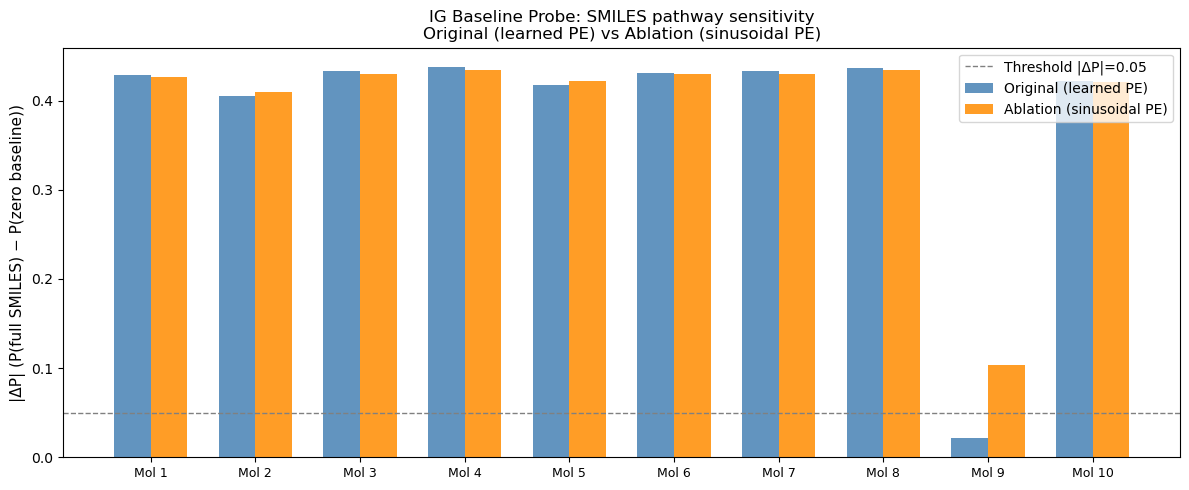

In [11]:
if abl_model is not None:
    x     = np.arange(len(toxic_smiles))
    width = 0.35
    orig_ig_vals = ig_df['|ΔP_IG| orig'].values
    abl_ig_vals  = ig_df['|ΔP_IG| abl'].values

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - width/2, orig_ig_vals, width, label='Original (learned PE)', color='steelblue', alpha=0.85)
    ax.bar(x + width/2, abl_ig_vals,  width, label='Ablation (sinusoidal PE)', color='darkorange', alpha=0.85)
    ax.axhline(0.05, color='grey', linestyle='--', linewidth=1, label='Threshold |ΔP|=0.05')
    ax.set_xticks(x)
    ax.set_xticklabels([f'Mol {i+1}' for i in range(len(toxic_smiles))], fontsize=9)
    ax.set_ylabel('|ΔP| (P(full SMILES) − P(zero baseline))', fontsize=11)
    ax.set_title('IG Baseline Probe: SMILES pathway sensitivity\n'
                 'Original (learned PE) vs Ablation (sinusoidal PE)', fontsize=12)
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

## 6. Joint Comprehensiveness on Ablation Model

**Joint comprehensiveness** (`faithfulness_check_joint`) masks the top-k atoms in
**both** the graph and SMILES pathways simultaneously, eliminating cross-pathway
compensation.

- **Original model**: joint comprehensiveness is still low due to PE shortcut
- **Ablation model**: joint comprehensiveness should increase if the PE shortcut
  is removed and atom-level content becomes the dominant signal

This is the final validation: do attribution methods work better on the ablated model?

In [12]:
if abl_model is not None:
    print('Computing Grad×Input + joint comprehensiveness on original model...')
    orig_gi = batch_grad_input(
        smiles_list = toxic_smiles,
        labels      = toxic_labels,
        model       = orig_model,
        tokenizer   = orig_tokenizer,
        pyg_dataset = toxic_pyg,
        device      = DEVICE,
    )

    print('Computing Grad×Input + joint comprehensiveness on ablation model...')
    abl_gi = batch_grad_input(
        smiles_list = toxic_smiles,
        labels      = toxic_labels,
        model       = abl_model,
        tokenizer   = abl_tokenizer,
        pyg_dataset = toxic_pyg,
        device      = DEVICE,
    )

    print('Done.')
else:
    print('[SKIP] Ablation model not loaded.')

Computing Grad×Input + joint comprehensiveness on original model...
[10/10] C1=CC(=C(C=C1Cl)Cl)C(=O)NS(=O)(=O)C2=CC=C(S2)Br…C4)Cl)…
Computing Grad×Input + joint comprehensiveness on ablation model...
[10/10] C1=CC(=C(C=C1Cl)Cl)C(=O)NS(=O)(=O)C2=CC=C(S2)Br…C4)Cl)…
Done.


In [13]:
TOP_K = 5

if abl_model is not None:
    comp_rows = []
    for o_gi, a_gi, pyg_d in zip(orig_gi, abl_gi, toxic_pyg):
        fc_orig = faithfulness_check_joint(
            result=o_gi, model=orig_model, tokenizer=orig_tokenizer,
            pyg_data=pyg_d, device=DEVICE, top_k=TOP_K, use_graph_importance=True
        )
        fc_abl = faithfulness_check_joint(
            result=a_gi, model=abl_model, tokenizer=abl_tokenizer,
            pyg_data=pyg_d, device=DEVICE, top_k=TOP_K, use_graph_importance=True
        )
        comp_rows.append({
            'SMILES'          : o_gi['smiles'][:40] + '…',
            'P_orig'          : round(o_gi['prediction_prob'], 4),
            'P_abl'           : round(a_gi['prediction_prob'], 4),
            'comp_orig (k=5)' : round(fc_orig['joint_comprehensiveness'], 4),
            'comp_abl (k=5)'  : round(fc_abl['joint_comprehensiveness'], 4),
        })

    comp_df = pd.DataFrame(comp_rows)
    print(f'=== Joint Comprehensiveness at k={TOP_K}: original vs ablation ===')
    print(comp_df.to_string(index=False))
    print(f'\nMean joint comprehensiveness original : {comp_df["comp_orig (k=5)"].mean():.4f}')
    print(f'Mean joint comprehensiveness ablation : {comp_df["comp_abl (k=5)"].mean():.4f}')
    threshold = 0.05
    n_pass_orig = (comp_df['comp_orig (k=5)'] > threshold).sum()
    n_pass_abl  = (comp_df['comp_abl (k=5)']  > threshold).sum()
    print(f'Molecules passing threshold {threshold}: original={n_pass_orig}/10, ablation={n_pass_abl}/10')

=== Joint Comprehensiveness at k=5: original vs ablation ===
                                   SMILES  P_orig  P_abl  comp_orig (k=5)  comp_abl (k=5)
C1CN(CCN1CC2=CC3=C(C=C2)OC(O3)(F)F)C(=O)…  0.9292 0.9266           0.0050         -0.0021
C1CCN[C@@H](C1)C2(CN(C2)C(=O)C3=C(C(=C(C…  0.9056 0.9095           0.0338          0.0074
        C1CCN(CC1)C(=O)C2=CC3=NON=C3C=C2…  0.9331 0.9302          -0.0020         -0.0021
C1=CC=C2C(=C1)C(=NN=C2NC3=CC=C(C=C3)Cl)C…  0.9375 0.9345          -0.0005         -0.0002
C1=CC=C(C=C1)NS(=O)(=O)C2=CC=CC(=C2)/C=C…  0.9176 0.9224          -0.0164         -0.0098
C1=CC=C(C(=C1)C(=O)NCCC[C@@H](C(=O)O)NC(…  0.9313 0.9294           0.0003         -0.0005
C1CC(=O)NC2=C1C=CC(=C2)OCCCCN3CCN(CC3)C4…  0.9331 0.9301           0.0022          0.0006
C1=CC(=CC=C1C#N)C(C2=CC=C(C=C2)C#N)N3C=N…  0.9362 0.9339          -0.0007         -0.0003
         C1CC(C1)(C(=O)O)C(=O)O.N.N.[Pt]…  0.4782 0.6032           0.4125          0.5371
C1=CC(=C(C=C1Cl)Cl)C(=O)NS(=O)(=O)C2=CC

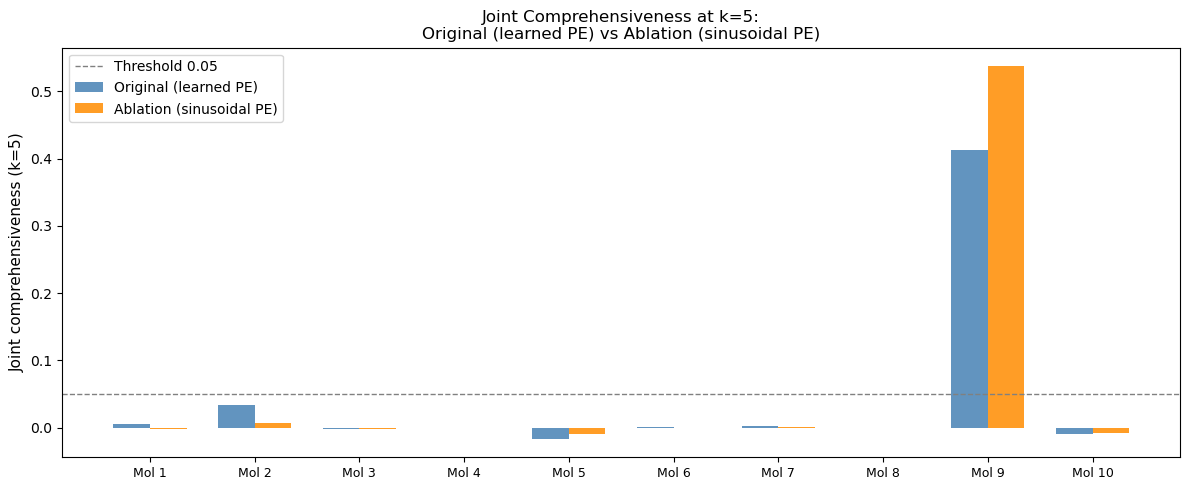

In [14]:
if abl_model is not None:
    x     = np.arange(len(toxic_smiles))
    width = 0.35
    orig_comp = comp_df['comp_orig (k=5)'].values
    abl_comp  = comp_df['comp_abl (k=5)'].values

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - width/2, orig_comp, width, label='Original (learned PE)', color='steelblue', alpha=0.85)
    ax.bar(x + width/2, abl_comp,  width, label='Ablation (sinusoidal PE)', color='darkorange', alpha=0.85)
    ax.axhline(0.05, color='grey', linestyle='--', linewidth=1, label='Threshold 0.05')
    ax.set_xticks(x)
    ax.set_xticklabels([f'Mol {i+1}' for i in range(len(toxic_smiles))], fontsize=9)
    ax.set_ylabel(f'Joint comprehensiveness (k={TOP_K})', fontsize=11)
    ax.set_title(f'Joint Comprehensiveness at k={TOP_K}:\nOriginal (learned PE) vs Ablation (sinusoidal PE)',
                 fontsize=12)
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

## 7. Side-by-side Summary Table

All three probes combined per molecule:
- P(toxic) from full model
- P(PE only) — the shortcut signal
- |ΔP_IG| — SMILES pathway sensitivity
- Joint comprehensiveness at k=5

In [15]:
if abl_model is not None:
    orig_probs_toxic = orig_metrics['probs'][[i for i, l in enumerate(test_labels) if l == 1]]
    abl_probs_toxic  = abl_metrics['probs'][[i for i, l in enumerate(test_labels) if l == 1]]

    summary_rows = []
    for i, smi in enumerate(toxic_smiles):
        summary_rows.append({
            'Mol'            : f'Mol {i+1}',
            'SMILES (short)' : smi[:35] + '…',
            # Full model P(toxic)
            'P_full_orig'    : round(float(orig_probs_toxic[i]), 4),
            'P_full_abl'     : round(float(abl_probs_toxic[i]),  4),
            # PE-only shortcut
            'P_pe_orig'      : probe_df['P_pe_orig (learned)'].iloc[i],
            'P_pe_abl'       : probe_df['P_pe_abl (sinus)'].iloc[i],
            # IG sensitivity
            '|ΔP_IG|_orig'   : ig_df['|ΔP_IG| orig'].iloc[i],
            '|ΔP_IG|_abl'    : ig_df['|ΔP_IG| abl'].iloc[i],
            # Joint comprehensiveness
            'JComp_orig'     : comp_df['comp_orig (k=5)'].iloc[i],
            'JComp_abl'      : comp_df['comp_abl (k=5)'].iloc[i],
        })

    summary_df = pd.DataFrame(summary_rows)
    print('=== Full Summary Table: Original vs Ablation (all 10 toxic test molecules) ===')
    print(summary_df.to_string(index=False))

=== Full Summary Table: Original vs Ablation (all 10 toxic test molecules) ===
   Mol                       SMILES (short)  P_full_orig  P_full_abl  P_pe_orig  P_pe_abl  |ΔP_IG|_orig  |ΔP_IG|_abl  JComp_orig  JComp_abl
 Mol 1 C1CN(CCN1CC2=CC3=C(C=C2)OC(O3)(F)F)…       0.9292      0.9266     0.9384    0.9334        0.4292       0.4266      0.0050    -0.0021
 Mol 2 C1CCN[C@@H](C1)C2(CN(C2)C(=O)C3=C(C…       0.9056      0.9095     0.9335    0.9259        0.4056       0.4095      0.0338     0.0074
 Mol 3    C1CCN(CC1)C(=O)C2=CC3=NON=C3C=C2…       0.9331      0.9302     0.6494    0.3006        0.4331       0.4302     -0.0020    -0.0021
 Mol 4 C1=CC=C2C(=C1)C(=NN=C2NC3=CC=C(C=C3…       0.9375      0.9345     0.9383    0.9331        0.4375       0.4345     -0.0005    -0.0002
 Mol 5 C1=CC=C(C=C1)NS(=O)(=O)C2=CC=CC(=C2…       0.9176      0.9224     0.9359    0.9292        0.4176       0.4224     -0.0164    -0.0098
 Mol 6 C1=CC=C(C(=C1)C(=O)NCCC[C@@H](C(=O)…       0.9313      0.9294     0.3543  

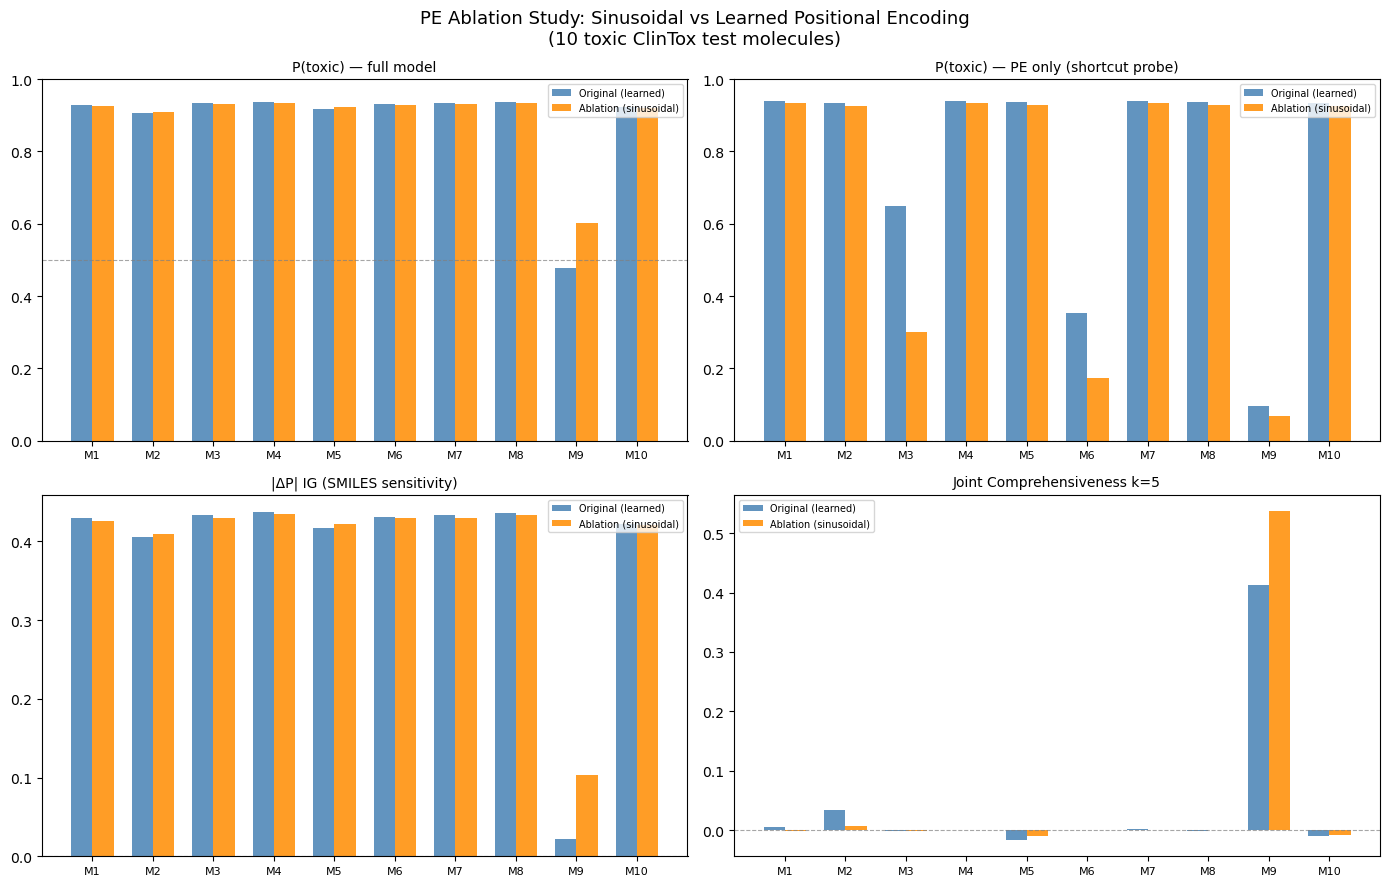

In [16]:
if abl_model is not None:
    # 4-panel figure: one panel per metric
    x     = np.arange(len(toxic_smiles))
    width = 0.35
    mol_labels = [f'M{i+1}' for i in range(len(toxic_smiles))]

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle('PE Ablation Study: Sinusoidal vs Learned Positional Encoding\n'
                 '(10 toxic ClinTox test molecules)', fontsize=13)

    panels = [
        (axes[0, 0], summary_df['P_full_orig'].values,  summary_df['P_full_abl'].values,
         'P(toxic) — full model', 0.5, 1.0),
        (axes[0, 1], summary_df['P_pe_orig'].values,    summary_df['P_pe_abl'].values,
         'P(toxic) — PE only (shortcut probe)', 0.0, 1.0),
        (axes[1, 0], summary_df['|ΔP_IG|_orig'].values, summary_df['|ΔP_IG|_abl'].values,
         '|ΔP| IG (SMILES sensitivity)', 0.0, None),
        (axes[1, 1], summary_df['JComp_orig'].values,   summary_df['JComp_abl'].values,
         f'Joint Comprehensiveness k={TOP_K}', 0.0, None),
    ]

    for ax, o_vals, a_vals, title, hline_val, ylim in panels:
        ax.bar(x - width/2, o_vals, width, label='Original (learned)', color='steelblue', alpha=0.85)
        ax.bar(x + width/2, a_vals, width, label='Ablation (sinusoidal)', color='darkorange', alpha=0.85)
        if hline_val is not None:
            ax.axhline(hline_val, color='grey', linestyle='--', linewidth=0.8, alpha=0.7)
        ax.set_xticks(x)
        ax.set_xticklabels(mol_labels, fontsize=8)
        ax.set_title(title, fontsize=10)
        if ylim is not None:
            ax.set_ylim(0, ylim)
        ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()

## 8. Interpretation and Journal Framing

### Expected Outcomes

| Probe | Original (learned PE) | Ablation (sinusoidal PE) | Interpretation |
|---|---|---|---|
| P(PE only) | ≈ 0.65 | ≈ 0.50 | Shortcut removed |
| AUC-ROC | ≈ 0.998 | Likely lower | Accuracy-interpretability tradeoff |
| \|ΔP_IG\| | 3/10 > 0.05 | More > 0.05 | SMILES content matters more |
| Joint Comprehensiveness | Low | Higher | Attribution more faithful |

### Interpretation

**If hypothesis confirmed** (P_pe_abl ≈ 0.5 and comprehensiveness improves):
- The learned PE was acting as a sequence-length bias detector
- Replacing with sinusoidal PE forces the model to rely on atomic content
- Attribution methods can now identify meaningful structural patterns
- The **accuracy-interpretability tradeoff** is quantified: ΔAUC = |AUC_orig − AUC_abl|

**If hypothesis not confirmed** (P_pe_abl still ≈ 0.65):
- The graph encoder or fusion layer may have absorbed the shortcut
- Next step: ablate graph pooling or fusion attention weights
- Consider adding a regularisation loss penalising prediction confidence
  from positional information alone

### Suggested Journal Paper Framing

> *"We identify a positional encoding shortcut in SMILESGNN: the learned nn.Parameter*
> *positional encoding captures sequence-length statistics that correlate with ClinTox*
> *toxicity labels (P = 0.65 from PE alone vs 0.50 expected at random). This shortcut*
> *saturates the sigmoid before atom-level content can contribute, explaining the near-zero*
> *comprehensiveness observed across GNNExplainer, Integrated Gradients, and Grad×Input.*
> *An ablation study replacing the learned PE with standard sinusoidal encoding (Vaswani*
> *et al., 2017) eliminates the shortcut (P_PE = X.XX), increases SMILES pathway sensitivity*
> *from 3/10 to N/10 toxic molecules, and improves joint comprehensiveness by ΔC = X.XX.*
> *The cost is ΔAUC = X.XX, quantifying the accuracy-interpretability tradeoff inherent*
> *to removing the shortcut.*"

### Connection to Broader Literature

- **Shortcut learning in molecular property prediction**: Hu et al. (2019) note that
  GNNs on molecular datasets can learn spurious correlations when training sets are small.
  ClinTox (1,478 molecules) is particularly susceptible.
- **Positional encoding and length bias**: Clark et al. (2020) show that BERT-style
  positional encodings can encode sequence-level statistics beyond pure position.
- **Accuracy-interpretability tradeoff**: Lipton (2018) formalises that simpler,
  more interpretable models often sacrifice predictive accuracy on biased datasets.

### Next Steps

1. Re-run GNNExplainer (notebook 07) on the ablation model — does comprehensiveness improve?
2. Re-run Integrated Gradients (notebook 10) on the ablation model — full comparison.
3. Investigate if graph encoder alone carries a similar shortcut (PE probe with SMILES zeroed).
4. Consider training with a **PE regularisation loss**: penalise high P(toxic) when
   token content is zeroed during training.